# Setup Notebook and Load Dataset

In [1]:
# Install openpyxl, which is required by pandas to read .xlsx files
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install xlrd>=2.0.1

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the path to your dataset
file_path = 'dataset.xls'

# Load the Excel file into a pandas DataFrame, using the first row as header and the first column as index
df = pd.read_excel(file_path, header=1, index_col=0)

# Display the first 5 rows of the DataFrame
display(df.head())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# Data Cleaning

## Variable Information

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
- X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
- X2: Gender (1 = male; 2 = female).
- X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
- X4: Marital status (1 = married; 2 = single; 3 = others).
- X5: Age (year).
- X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
- X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
- X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.
- Y: Result of data mining study of dataset author

## Dataset Exploration

In [4]:
# Display the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 30000
Number of columns: 24


In [5]:
# Display attributes and their data types
print("\nData types and non-null values:")
df.info()


Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-n

## Handling Duplicates

In [6]:
# Identify duplicate rows by sorting all rows
duplicate_rows_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(f"Number of duplicate rows: {len(duplicate_rows_df)}")

# Show which rows are duplicates of each other
if not duplicate_rows_df.empty:
    print("\nAll duplicate rows (sorted to show matches):")
    display(duplicate_rows_df.head(10))
else:
    print("No duplicate rows found.")

Number of duplicate rows: 70

All duplicate rows (sorted to show matches):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
12431,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14295,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1760,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10251,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7171,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17033,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7367,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
19115,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
21769,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Drop duplicate rows, keeping the first occurrence
df.drop_duplicates(inplace=True)

print(f"DataFrame shape after dropping duplicate rows: {df.shape}")

DataFrame shape after dropping duplicate rows: (29965, 24)


## Handling Missing Data

In [8]:
# Check for missing values in absolute numbers
missing_data = df.isnull().sum()
print("Absolute number of missing values per column:\n")
print(missing_data[missing_data > 0])

# Check for missing values in percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values per column:\n")
print(missing_percentage[missing_percentage > 0].apply(lambda x: f"{x:.2f}%"))

Absolute number of missing values per column:

Series([], dtype: int64)

Percentage of missing values per column:

Series([], dtype: float64)


# Data Transformation

## Data Type Conversion and Separation


In [9]:
# Define columns that should be categorical
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default payment next month']

# Convert specified columns to 'category' dtype
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping category conversion.")

# Display data types again to confirm changes
print("\nData types after conversion:")
df.info()


Data types after conversion:
<class 'pandas.DataFrame'>
Index: 29965 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   29965 non-null  int64   
 1   SEX                         29965 non-null  category
 2   EDUCATION                   29965 non-null  category
 3   MARRIAGE                    29965 non-null  category
 4   AGE                         29965 non-null  int64   
 5   PAY_0                       29965 non-null  category
 6   PAY_2                       29965 non-null  category
 7   PAY_3                       29965 non-null  category
 8   PAY_4                       29965 non-null  category
 9   PAY_5                       29965 non-null  category
 10  PAY_6                       29965 non-null  category
 11  BILL_AMT1                   29965 non-null  int64   
 12  BILL_AMT2                   29965 non-null  int64   
 13  BI

In [10]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['category']).columns.tolist()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Numerical Columns: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical Columns: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default payment next month']


In [11]:
# Display unique values for categorical columns
print("\nUnique values for Categorical Columns:")
for col in cat_cols:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

# Unify 'EDUCATION' column: change 4, 5, 6 to 0 to indicate 'others'
df['EDUCATION'] = df['EDUCATION'].replace([4, 5, 6], 0)
print("\nUnique values for EDUCATION after remapping:")
print(sorted(df['EDUCATION'].unique().tolist()))


Unique values for Categorical Columns:
  SEX: [1, 2]
  EDUCATION: [0, 1, 2, 3, 4, 5, 6]
  MARRIAGE: [0, 1, 2, 3]
  PAY_0: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_2: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_3: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_4: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_5: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
  PAY_6: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
  default payment next month: [0, 1]

Unique values for EDUCATION after remapping:
[0, 1, 2, 3]


## Normalization


Box Plots of Numerical Columns (Before Scaling):


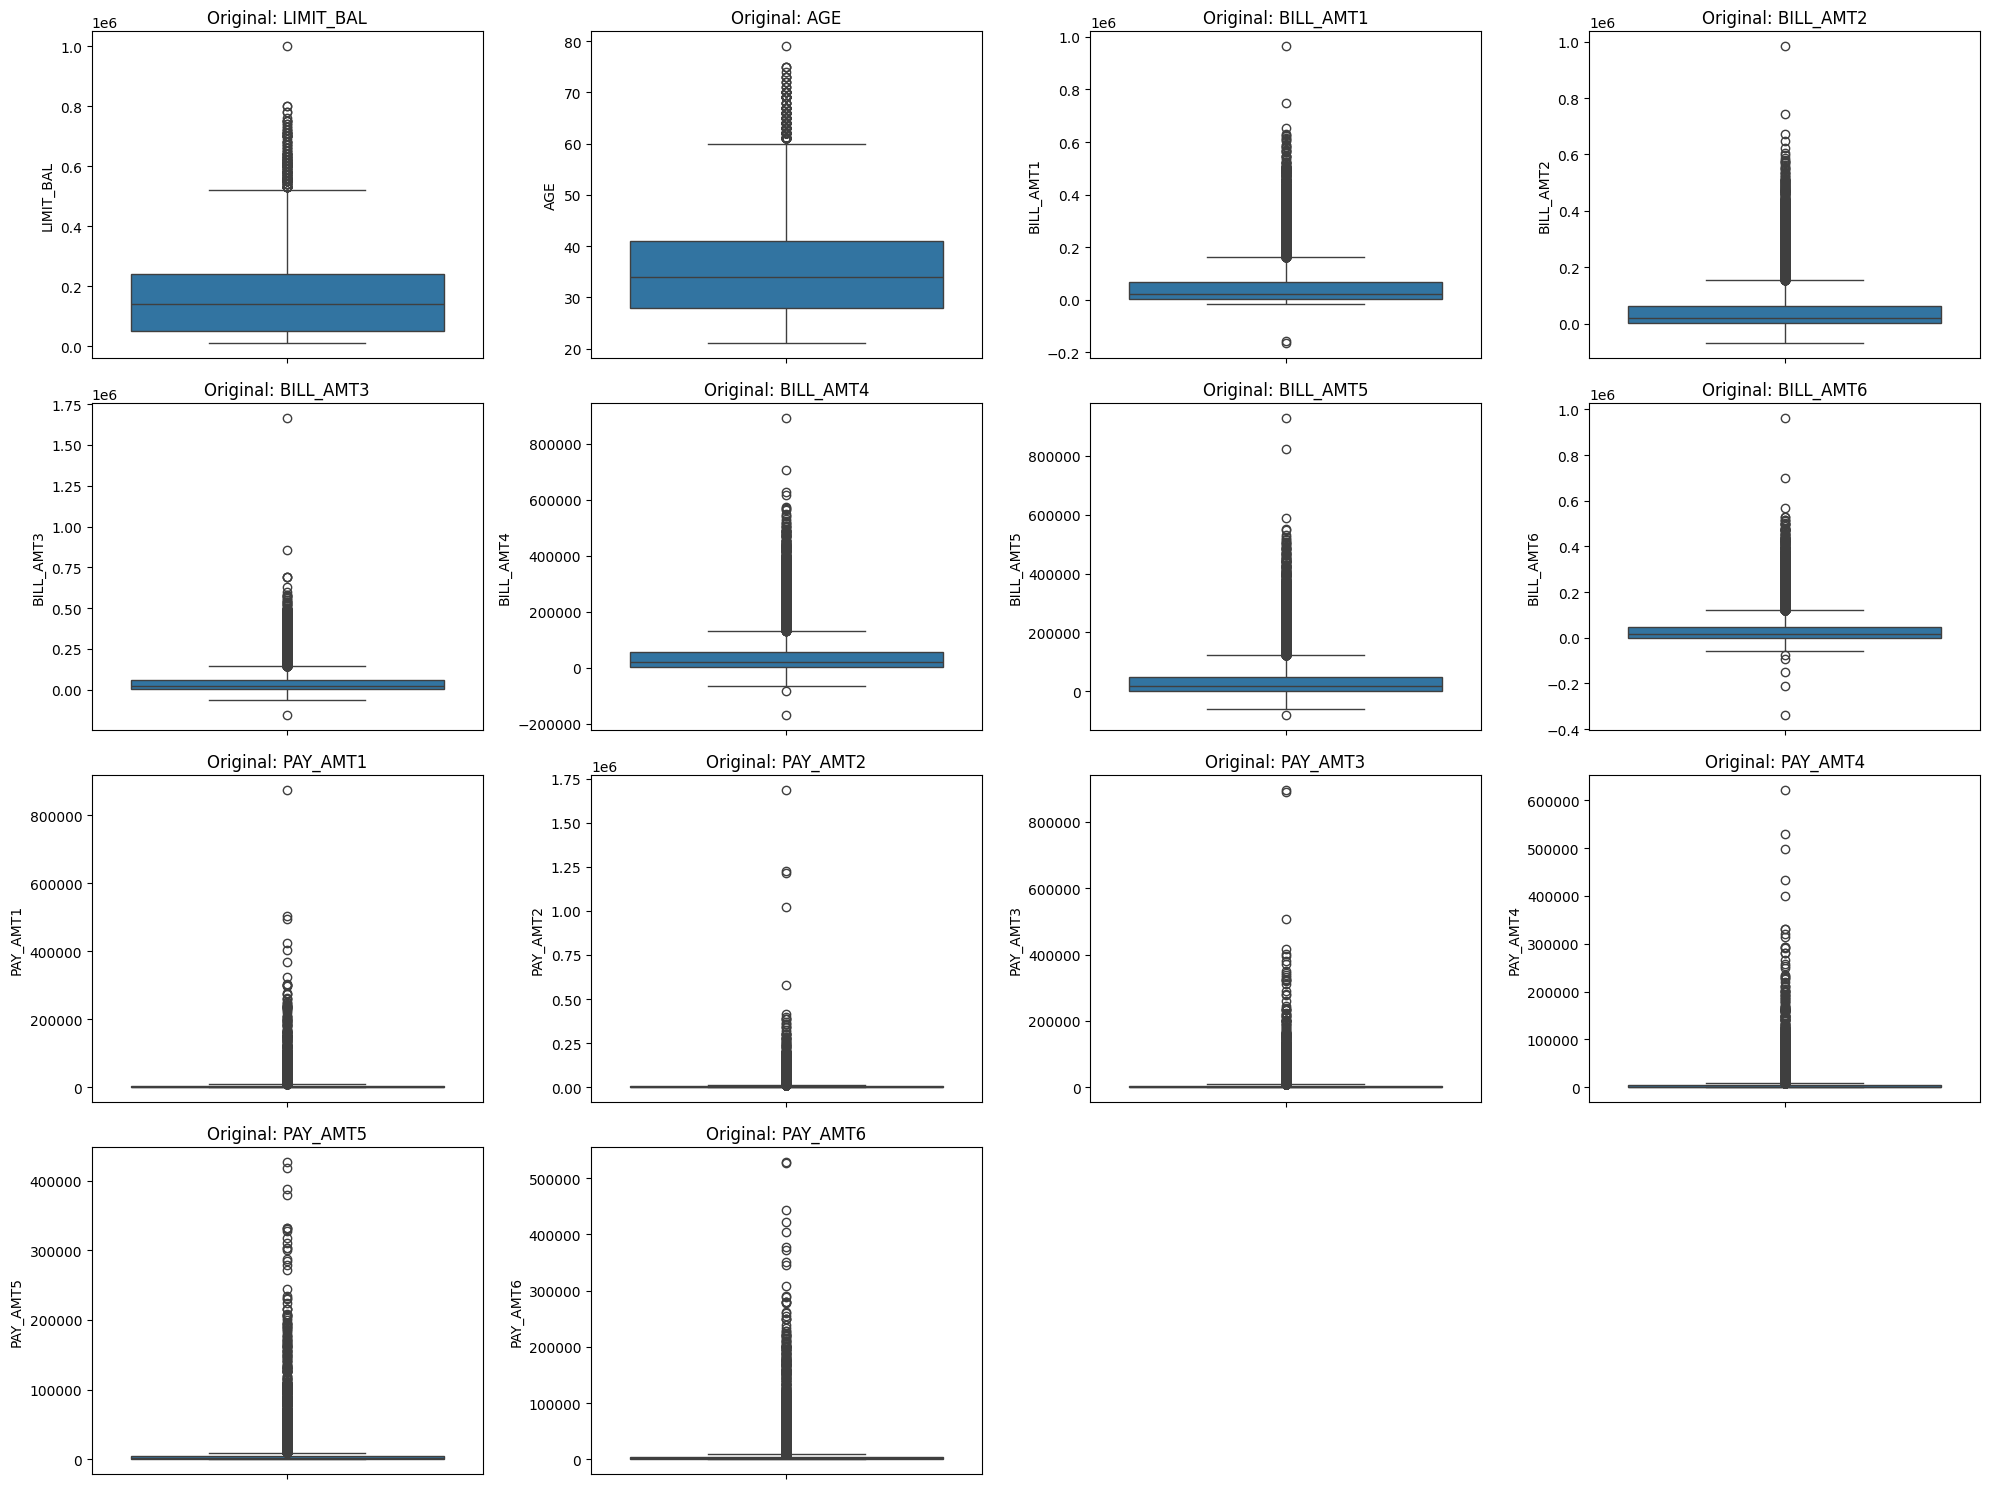

In [12]:
# Box plots before any scaling
print("\nBox Plots of Numerical Columns (Before Scaling):")
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f'Original: {col}')
plt.tight_layout()
plt.show()


Box Plots of Numerical Columns (After Scaling):


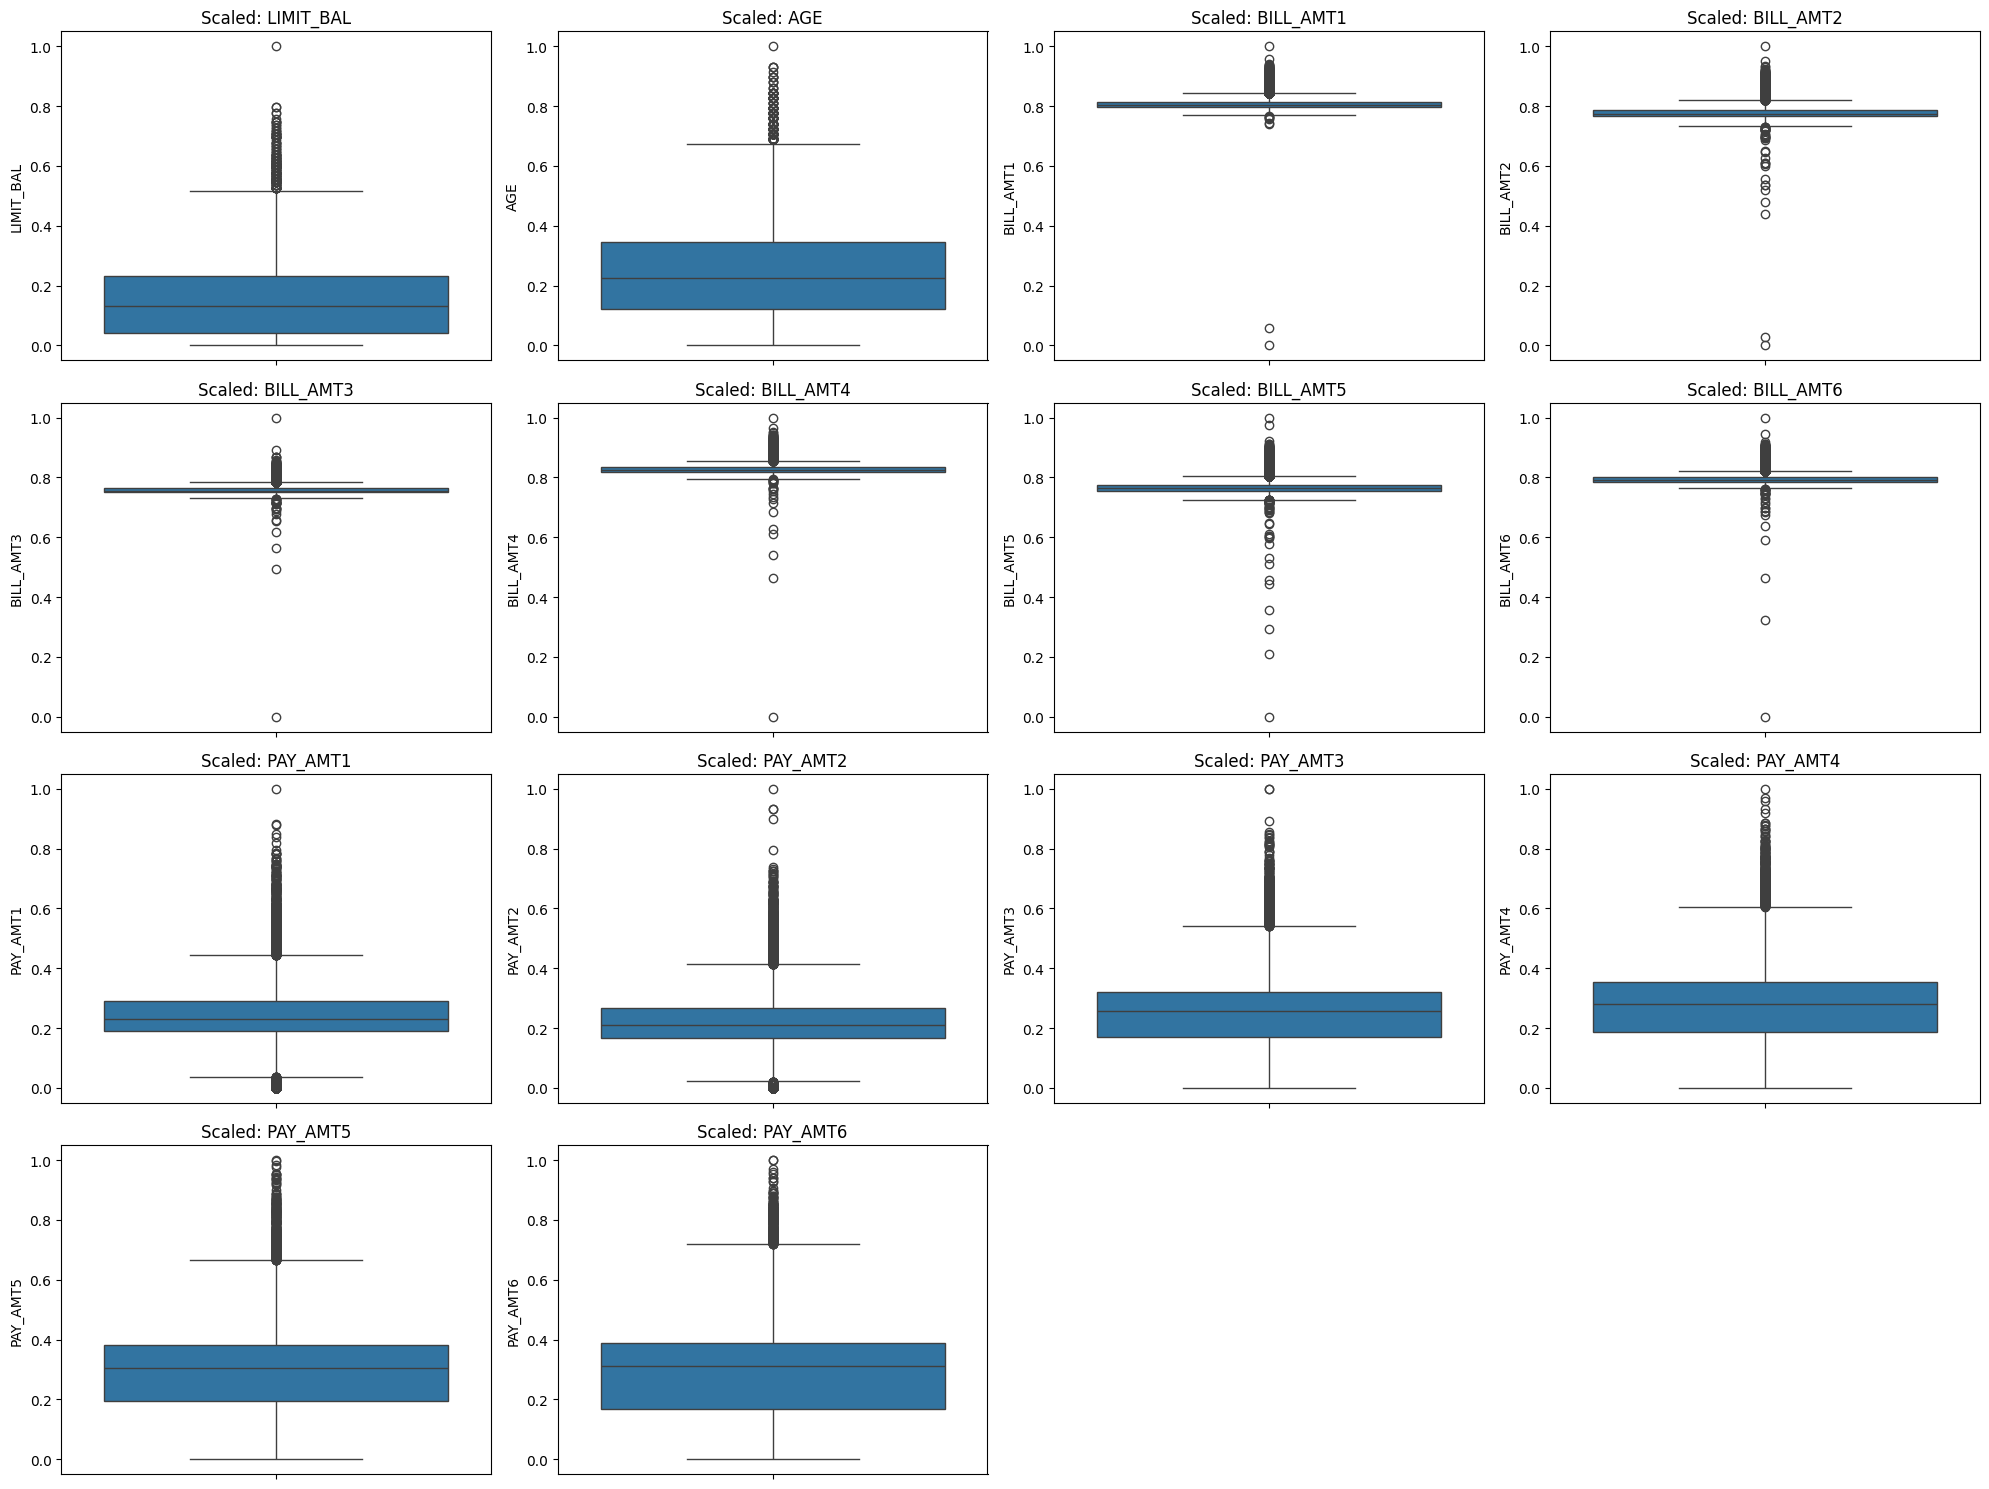

In [13]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

df_scaled = df.copy()
highly_skewed = [f'BILL_AMT{x}' for x in range(1, 7)] + [f'PAY_AMT{x}' for x in range(1, 7)]

# Apply power transformation to the highly skewed columns
power_transformer = PowerTransformer(method='yeo-johnson')
df_scaled[highly_skewed] = power_transformer.fit_transform(df_scaled[highly_skewed])

# Apply Min-Max Scaling to all numerical columns
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

# Box plots after Yeo-Johnson scaling
print("\nBox Plots of Numerical Columns (After Scaling):")
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_scaled[col])
    plt.title(f'Scaled: {col}')
plt.tight_layout()
plt.show()

## SMOTENC

In [14]:
!pip install imbalanced-learn


Distribution of 'default payment next month' (Original):


C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\1272991735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['default payment next month'], palette='viridis')


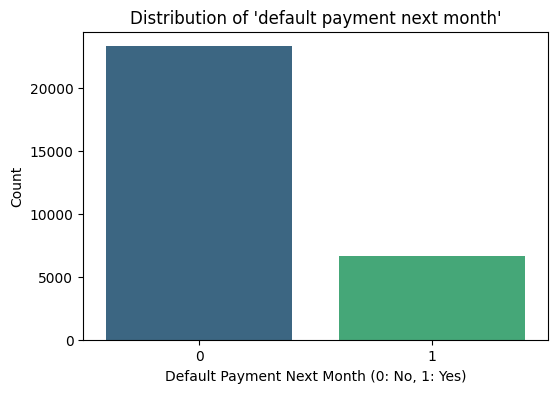

default payment next month
0    23335
1     6630
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

# Check distribution of 'default payment next month' column
print("\nDistribution of 'default payment next month' (Original):")
plt.figure(figsize=(6, 4))
sns.countplot(x=df['default payment next month'], palette='viridis')
plt.title("Distribution of 'default payment next month'")
plt.xlabel("Default Payment Next Month (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()
print(df['default payment next month'].value_counts())

In [16]:
# Split dataset into testing and training
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']
X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, random_state=0, stratify=y)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Original y_test shape: {y_test.shape}")


Original X_train shape: (23972, 23)
Original y_train shape: (23972,)
Original X_test shape: (5993, 23)
Original y_test shape: (5993,)



Distribution of 'default payment next month' in Training and Test Sets:


C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\1409911215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\1409911215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='viridis')


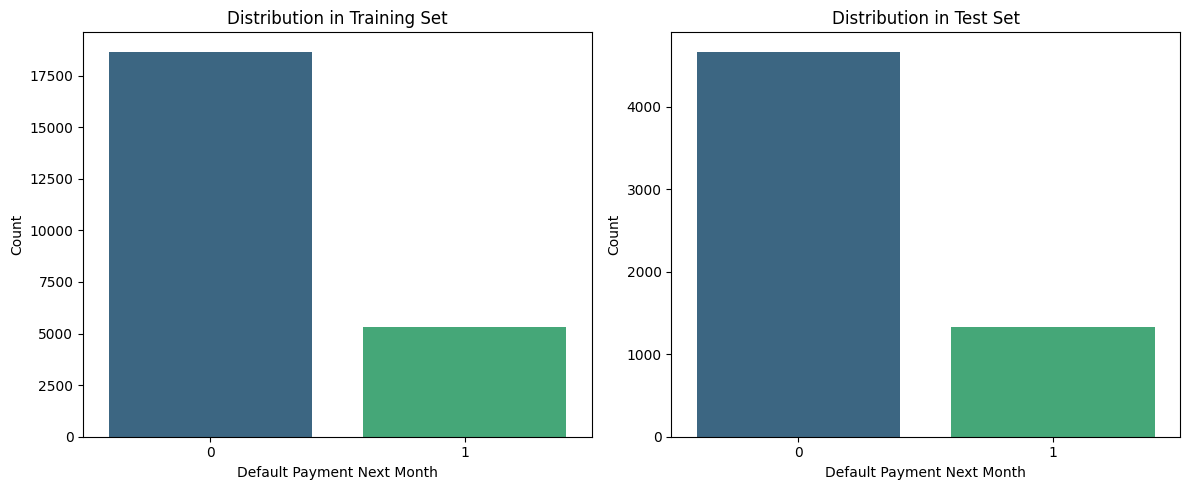

Training Set Distribution:
0    18668
1     5304
Name: count, dtype: int64

Test Set Distribution:
0    4667
1    1326
Name: count, dtype: int64


In [17]:
# Plot distribution for both testing and training set against y
print("\nDistribution of 'default payment next month' in Training and Test Sets:")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title("Distribution in Training Set")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='viridis')
plt.title("Distribution in Test Set")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("Training Set Distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest Set Distribution:")
print(pd.Series(y_test).value_counts())

In [18]:
# Use SMOTENC to balance dataset
categorical_features_indices = [X.columns.get_loc(col) for col in cat_cols if col in X.columns]

smotenc = SMOTENC(categorical_features=categorical_features_indices, random_state=0)
X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train, y_train)

print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")

X_train_resampled shape: (37336, 23)
y_train_resampled shape: (37336,)



Distribution of 'default payment next month' (After SMOTENC on Training Set):


C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\1521516265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


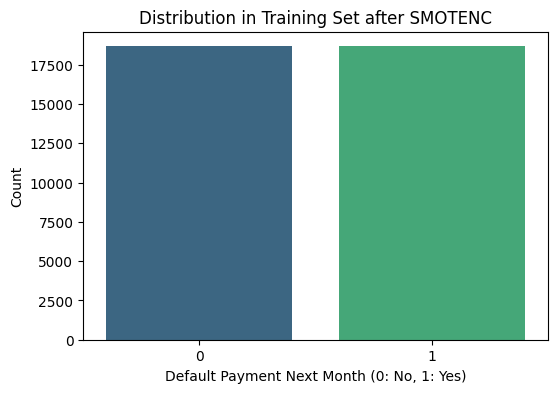

Resampled Training Set Distribution:
0    18668
1    18668
Name: count, dtype: int64


In [19]:
# Plot new distribution of training set
print("\nDistribution of 'default payment next month' (After SMOTENC on Training Set):")
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='viridis')
plt.title("Distribution in Training Set after SMOTENC")
plt.xlabel("Default Payment Next Month (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()

print("Resampled Training Set Distribution:")
print(pd.Series(y_train_resampled).value_counts())

## One-hot Encoding

In [20]:
onehot_cols = cat_cols.remove('default payment next month')

# Convert training and testing data into one-hot encoding
X_combined = pd.concat([X_train_resampled, X_test], axis=0)
X_combined_onehot = pd.get_dummies(X_combined, columns=onehot_cols, drop_first=True)

# Split them back
X_train_onehot = X_combined_onehot.iloc[:len(X_train_resampled)]
X_test_onehot = X_combined_onehot.iloc[len(X_train_resampled):]

print("Shapes after one-hot encoding and splitting:")
print(f"X_train_onehot shape: {X_train_onehot.shape}")
print(f"X_test_onehot shape: {X_test_onehot.shape}")

Shapes after one-hot encoding and splitting:
X_train_onehot shape: (37336, 82)
X_test_onehot shape: (5993, 82)


# EDA

## 7. Exploratory Data Analysis (EDA)

In [21]:
# Central tendencies for numerical data
print("\nDescriptive Statistics for Numerical Columns:")
display(df[num_cols].describe())

# Central tendencies for categorical data
print("\nDescriptive Statistics for Categorical Columns:")
display(df[cat_cols].describe())


Descriptive Statistics for Numerical Columns:


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,35.487969,51283.009778,49236.366294,4.706792e+04,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014
std,129760.135222,9.219459,73658.132403,71195.567392,6.937135e+04,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3595.000000,3010.000000,2.711000e+03,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000
50%,140000.000000,34.000000,22438.000000,21295.000000,2.013500e+04,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67260.000000,64109.000000,6.020100e+04,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000



Descriptive Statistics for Categorical Columns:


,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,29965,29965,29965,29965,29965,29965,29965,29965,29965
unique,2,4,4,11,11,11,11,10,10
top,2,2,2,0,0,0,0,0,0
freq,18091,14019,15945,14737,15730,15764,16455,16947,16286



Histograms for Numerical Columns:


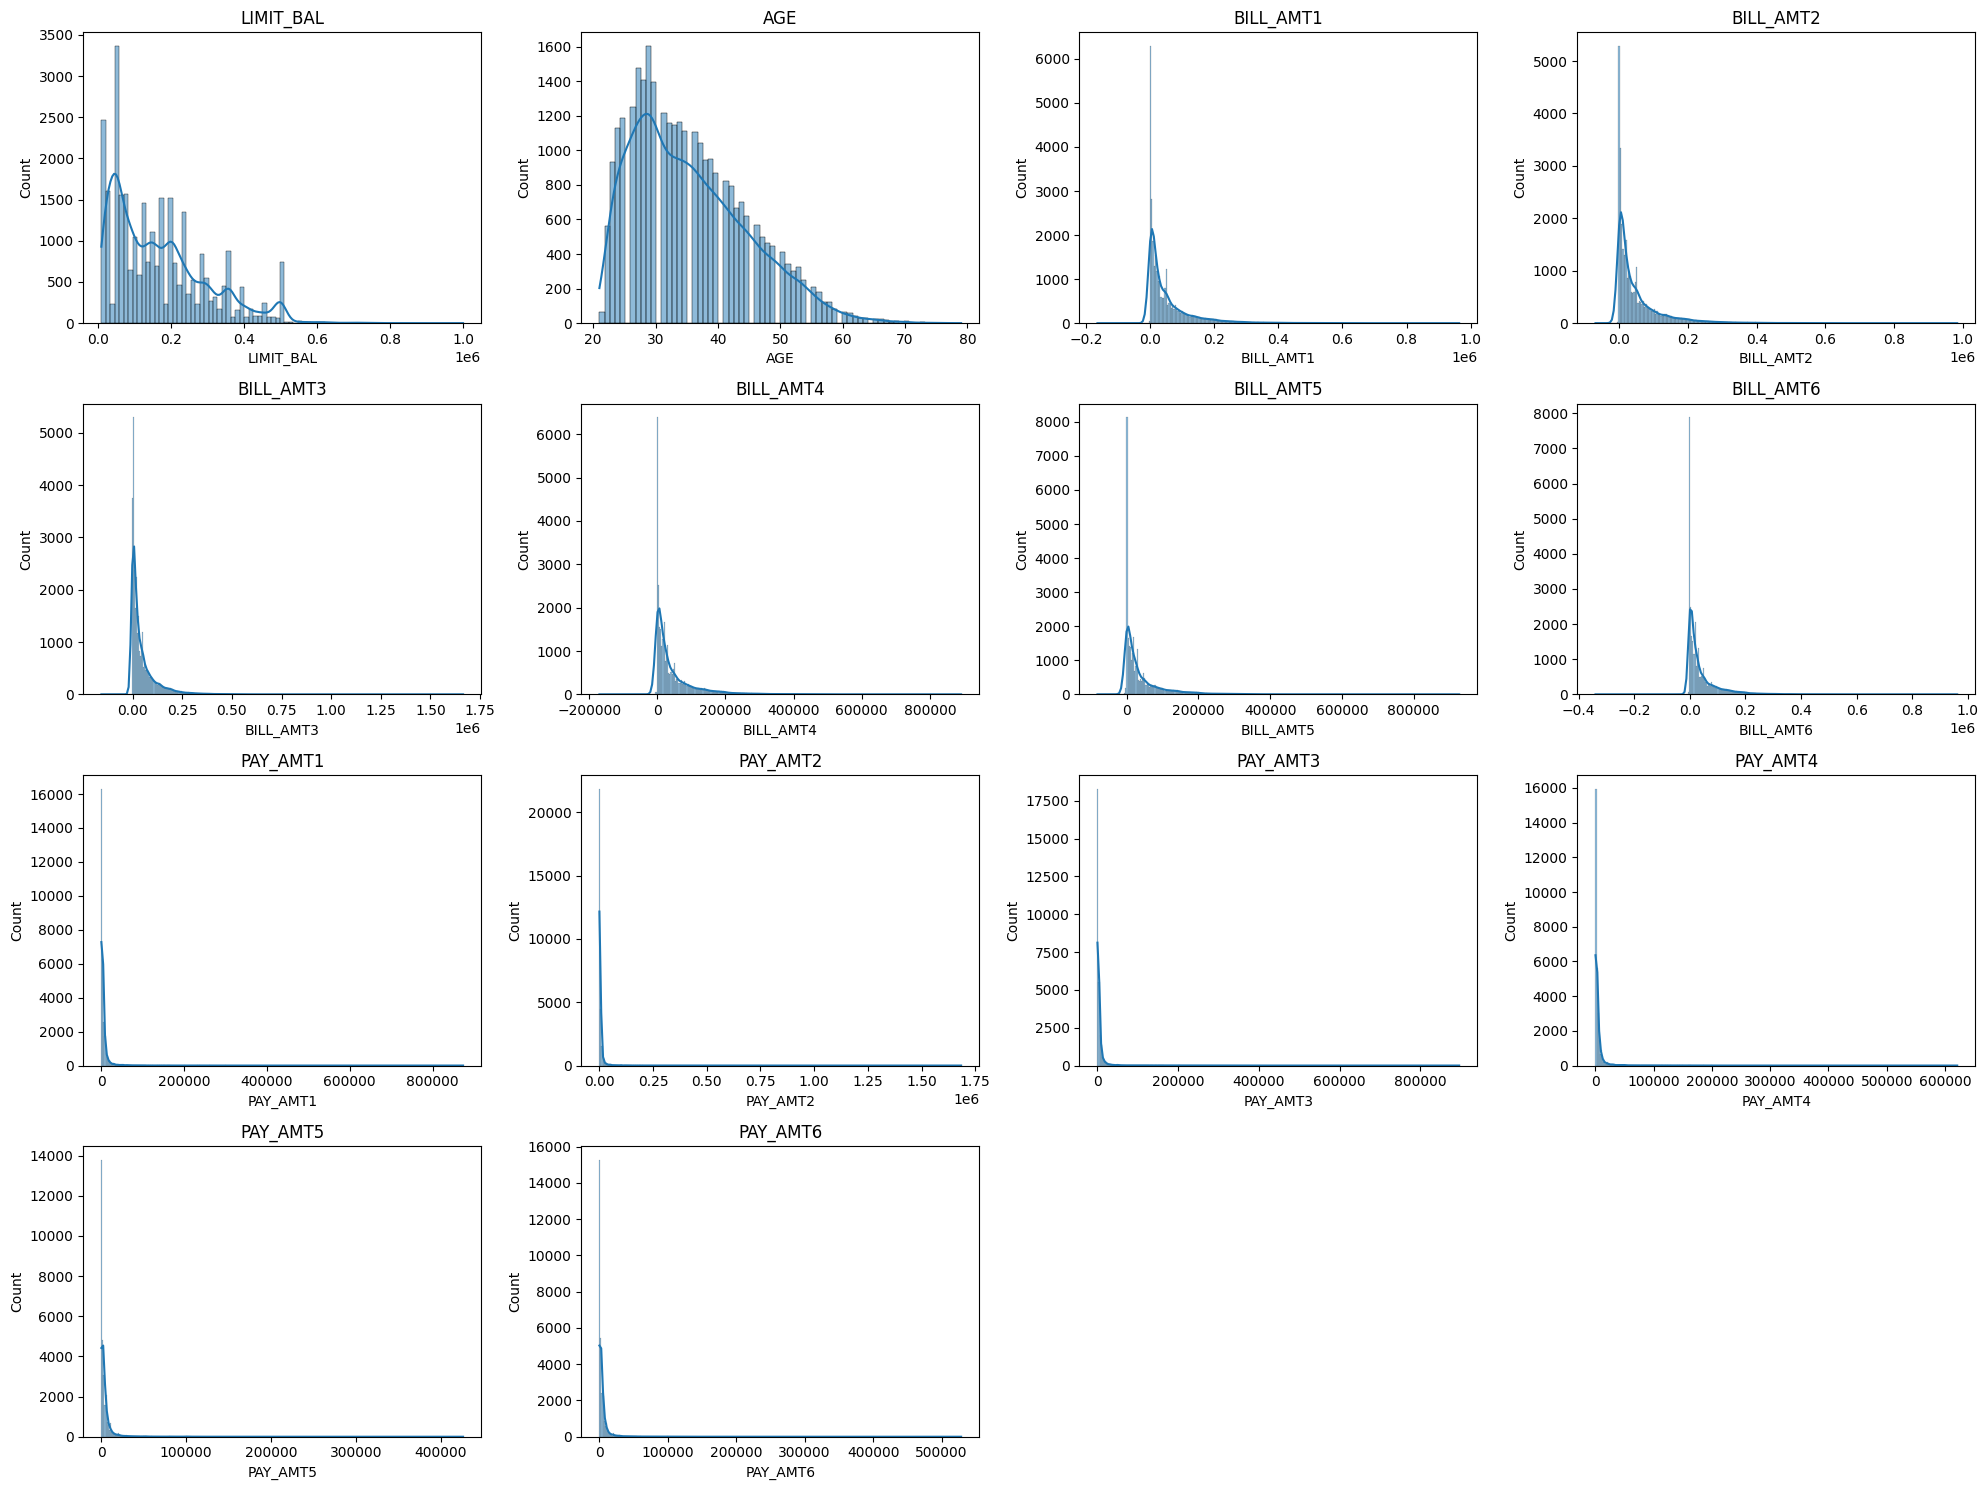

In [22]:
# Plot histograms for numerical columns
print("\nHistograms for Numerical Columns:")
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i) # Adjust grid size as needed
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


Bar Plots for Categorical Columns:


C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\3143460373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\3143460373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\3143460373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
C:\Users\wxing\AppData\Local\Temp\ipykernel_35500\3143460373.py:6: FutureWarning: 

Passing `palette` without as

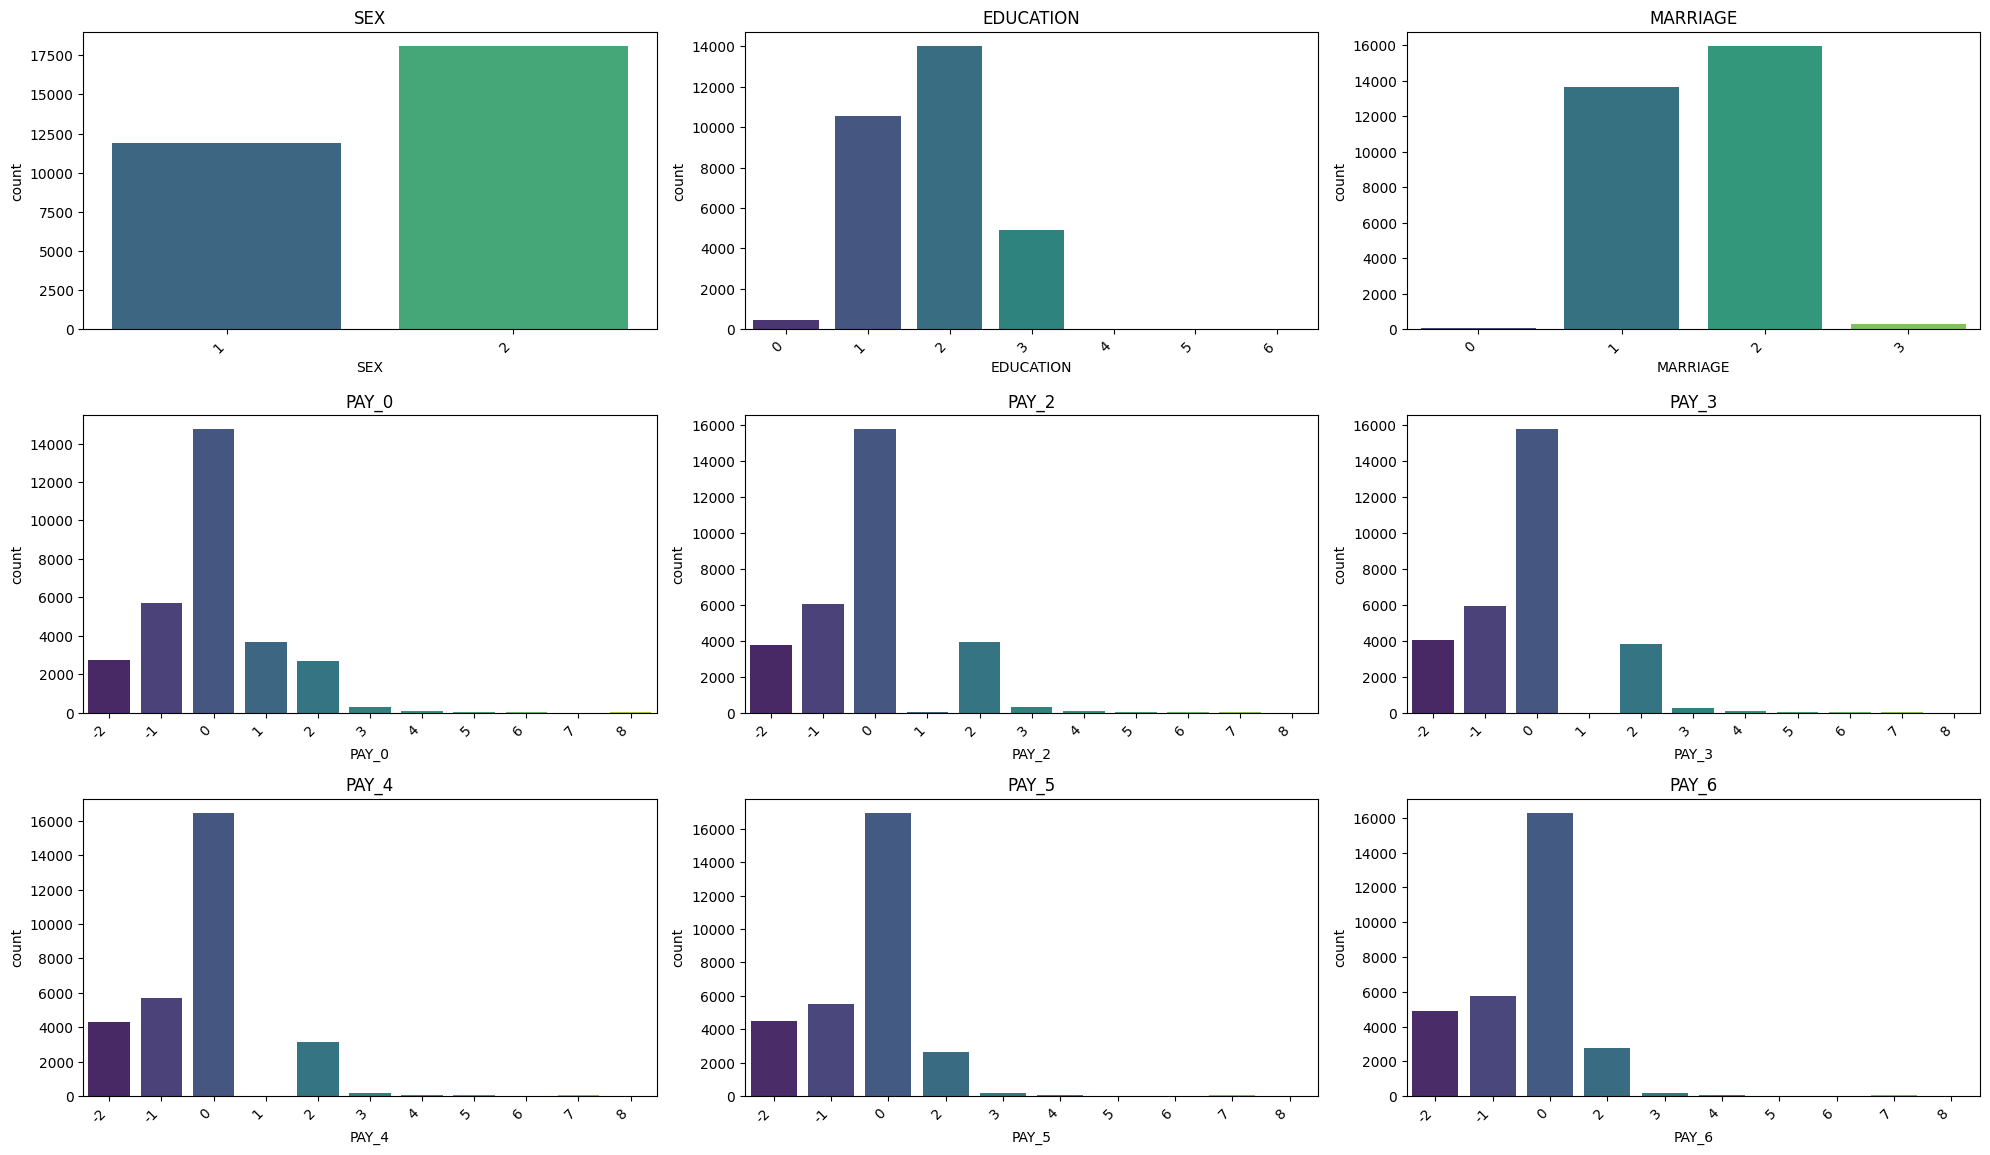

In [23]:
# Plot bar plots for categorical columns
print("\nBar Plots for Categorical Columns:")
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 3, i) # Adjusted grid size to 4 rows and 3 columns
    sns.countplot(x=df[col], palette='viridis')
    plt.title(col)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize pairplot to identify correlation
print("\nPairplot of Numerical Columns:")
sns.pairplot(df[num_cols])
plt.show()

# Data Reduction



## Principal Component Analysis (PCA)

In [24]:
from sklearn.decomposition import PCA

# "Give me the minimum number of components needed to retain 95% variance"
pca_95 = PCA(n_components=0.95)
X_train_reduced = pca_95.fit_transform(X_train_onehot)
X_test_reduced = pca_95.transform(X_test_onehot)

print(f"Original features: {X_train_onehot.shape[1]}")
print(f"Reduced features to hit 95% variance: {pca_95.n_components_}")

Original features: 82
Reduced features to hit 95% variance: 3


# Baseline Classification

## Utility Functions

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

def store_metrics(model, dict, x_test, y_test):
    # Store performance scores
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    dict[model] = (accuracy, precision, recall)

# options: [score, report, cm]
def pretty_print_metrics(model, dict, x_test, y_test, options):
    print(f"\nMetrics for {model}:")
    for opt in options:
        if opt == 'score':
            # Print model performance scores
            accuracy, precision, recall = dict[model]
            print(f"Accuracy:  {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall:    {recall:.4f}\n")

        elif opt == 'report':
            # Print classification report
            y_pred = model.predict(x_test)
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred))

        elif opt == 'cm':
            # Confusion Matrix
            y_pred = model.predict(x_test)
            cm = confusion_matrix(y_test, y_pred, normalize='true')
            tn, fp, fn, tp = cm.ravel()
            print(f"True Positives (TP): {tp}")
            print(f"True Negatives (TN): {tn}")
            print(f"False Positives (FP): {fp}")
            print(f"False Negatives (FN): {fn}")

            # Plot Confusion Matrix
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                        xticklabels=['No Default', 'Default'],
                        yticklabels=['No Default', 'Default'])
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix (lbfgs)')
            plt.show()

        else:
            raise ValueError("Invalid option.")

## Results of Models

In [ ]:
# Try Logistic Regression with different parameters
from sklearn.linear_model import LogisticRegression

# Create dictionary to store performance
# Format: (accuracy, precision, recall) all results are from testing set
performance = {}

# no pca
for solver in ['newton-cg', 'lbfgs', 'liblinear', 'saga']:
    model = LogisticRegression(solver=solver, random_state=0)
    model.fit(X_train_onehot, y_train_resampled)
    store_metrics(model, performance, X_test_onehot, y_test)

for model in performance:
    pretty_print_metrics(model, performance, X_test_onehot, y_test, ['score'])


In [ ]:
from sklearn.linear_model import LogisticRegression

performance = {}

# pca retain 95% variance
for solver in ['newton-cg', 'lbfgs', 'liblinear', 'saga']:
    model = LogisticRegression(solver=solver, random_state=0)
    model.fit(X_train_reduced, y_train_resampled)
    store_metrics(model, performance, X_test_reduced, y_test)

for model in performance:
    pretty_print_metrics(model, performance, X_test_reduced, y_test, ['score'])

In [ ]:
# Initialize Logistic Regression with LASSO (L1) penalty
# C is the inverse of regularization strength (smaller C = stronger penalty)
model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1, random_state=0)
model.fit(X_train_onehot, y_train_resampled)
store_metrics(model, performance, X_test_onehot, y_test)
pretty_print_metrics(model, performance, X_test_onehot, y_test, ['score'])

In [ ]:
# Initialize Logistic Regression with LASSO (L1) penalty
# C is the inverse of regularization strength (smaller C = stronger penalty)
model = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=0, class_weight='balanced')
model.fit(X_train_onehot, y_train_resampled)
store_metrics(model, performance, X_test_onehot, y_test)
pretty_print_metrics(model, performance, X_test_onehot, y_test, ['score'])

In [ ]:
model = LogisticRegression(l1_ratio=1, solver='liblinear', random_state=0, C=0.1)
model.fit(X_train_onehot, y_train_resampled)
store_metrics(model, performance, X_test_onehot, y_test)
pretty_print_metrics(model, performance, X_test_onehot, y_test, ['score'])

In [ ]:
model = LogisticRegression(l1_ratio=0.5, solver='saga', random_state=0, class_weight='balanced')
model.fit(X_train_onehot, y_train_resampled)
store_metrics(model, performance, X_test_onehot, y_test)
pretty_print_metrics(model, performance, X_test_onehot, y_test, ['score'])

In [ ]:
# Convert scores in dictionary into a DataFrame
performance_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Accuracy', 'Precision', 'Recall'])

# Sort by Precision in descending order
performance_df_sorted = performance_df.sort_values(by='Precision', ascending=False)

print("\nLogistic Regression Solver Performance:")
display(performance_df_sorted)

# Identify the best model based on Precision
best_model = performance_df_sorted.index[0]
print(f"\nThe best performing model based on Precision is '{best_model}'.")

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Random Forest model
model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=0)
model.fit(X_train_reduced, y_train_resampled)
store_metrics(model, performance, X_test_reduced, y_test)
pretty_print_metrics(model, performance, X_test_reduced, y_test, ['score', 'report'])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the forest with structural constraints to prevent overfitting
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,               # Keep depth controlled so it doesn't overfit
    min_samples_leaf=5,         # Prevents leaves from isolating tiny noise
    class_weight='balanced_subsample', # Mandate focus on the minority class
    random_state=42,
    n_jobs=-1                  # Uses all CPU cores to speed up training
)

model.fit(X_train_resampled, y_train_resampled)

store_metrics(model, performance, X_test, y_test)
pretty_print_metrics(model, performance, X_test, y_test, ['score', 'report'])

## Extract Model Weights

In [ ]:
# Get coefficients from the best performing model (newtoncholesky)
coefficients = log_reg_newtoncholesky.coef_[0]
feature_names = X_train_onehot.columns

# Create a DataFrame to display feature weights
feature_weights = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort the feature weights by absolute coefficient value for better readability
feature_weights['Abs_Coefficient'] = feature_weights['Coefficient'].abs()
feature_weights_sorted = feature_weights.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("\nFeature Weights for 'newtoncholesky' solver:")
display(feature_weights_sorted)

In [26]:
!pip install xgboost

In [28]:
# 1. Import library
import xgboost as xgb

# Initialize the XGBoost Classifier
# Optional: handle class imbalance by setting scale_pos_weight = count(Negative) / count(Positive)
best_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Train the model (assuming X_train and y_train are already preprocessed)
best_xgb_model.fit(X_train, y_train)

# 2. Check what 'best_xgb_model' actually is
print(f"Is this an XGBoost model? {isinstance(best_xgb_model, xgb.XGBClassifier)}")

# 3. Save it
best_xgb_model.save_model("xgboost_credit_model.json")
print("Saved successfully!")

Is this an XGBoost model? True
Saved successfully!


In [ ]:
import xgboost as xgb
import pickle

# Initialize the XGBoost Classifier
# Optional: handle class imbalance by setting scale_pos_weight = count(Negative) / count(Positive)
best_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Train the model (assuming X_train and y_train are already preprocessed)
best_xgb_model.fit(X_train, y_train)

# Export the model using pickle
with open('xgboost_credit_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_model, f)

# In your notebook
model.save_model("xgboost_credit_model.json")